In [3]:
# Descarga los laberintos desde el repositorio del taller.
# Se usa el repo en vez de Google Drive para que el notebook corra igual en
# cualquier cuenta, sin depender de cómo esté organizada una carpeta personal.
import os

REPO_URL = "https://github.com/SarahGomez/IA_WorkShop.git"
REPO_DIR = "/content/IA_WorkShop"

# Solo clona la primera vez: volver a ejecutar la celda no falla.
if not os.path.exists(REPO_DIR):
    !git clone --quiet $REPO_URL $REPO_DIR
else:
    print("El repositorio ya estaba descargado.")

%cd $REPO_DIR/WORKSHOP2

/content/IA_WorkShop/WORKSHOP2


In [4]:
# Comprobación del setup: si esta celda falla, ninguna de las siguientes va a
# funcionar, porque todas cargan los laberintos con rutas relativas a mazes/.
from pathlib import Path

ESPERADOS = ["maze1.txt", "maze2.txt", "maze3_sin_solucion.txt"]

print("Directorio de trabajo:", Path.cwd())
print("\nLaberintos encontrados:")

for nombre in ESPERADOS:
    ruta = Path("mazes") / nombre
    estado = "ok" if ruta.exists() else "FALTA"
    print(f"  [{estado}] {ruta}")

faltantes = [n for n in ESPERADOS if not (Path("mazes") / n).exists()]
assert not faltantes, (
    f"Faltan laberintos: {faltantes}. Revisa que la celda anterior haya "
    f"clonado el repositorio y hecho cd a WORKSHOP2."
)

Directorio de trabajo: /content/IA_WorkShop/WORKSHOP2

Laberintos encontrados:
  [ok] mazes/maze1.txt
  [ok] mazes/maze2.txt
  [ok] mazes/maze3_sin_solucion.txt


# Búsqueda en laberintos: la misma arquitectura, otro problema

**Curso:** SI3003 — Inteligencia Artificial

1. **Cómo se representa el problema** (`Maze` en vez de un diccionario `graph`).
2. **Cómo se generan los vecinos de un estado** (`maze.neighbors(state)` en vez de `graph[state]`).

Si ya resolviste el notebook de grafos, cada célula de código de la Parte 1 debería resultarte familiar: es el mismo algoritmo, aplicado a un problema donde los estados son coordenadas `(fila, columna)` en vez de letras.



## 1. Problema de búsqueda

- **Estado inicial:** la celda marcada con `A`.
- **Estado objetivo:** la celda marcada con `B`.
- **Estados:** todas las celdas transitables del laberinto.
- Los muros (`#`) no son estados válidos.

A diferencia del grafo `A → H` del notebook anterior, aquí **no tenemos la lista de vecinos escrita a mano**: hay que calcularla a partir de la posición `(fila, columna)` y del layout del laberinto.

In [5]:
from __future__ import annotations

from pathlib import Path
from itertools import count
import heapq

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


MAZES_DIR = Path("mazes")

## 2. Representación del problema

En el grafo, cada vecino era una tupla `(estado_vecino, costo_de_la_arista)`:

```python
graph = {
    "A": [("B", 2), ("C", 1)],
    ...
}
```

En el laberinto **no escribimos esa lista a mano** — la calculamos con un método `neighbors(state)` que:

1. Genera las cuatro celdas adyacentes (arriba, abajo, izquierda, derecha).
2. Descarta las que caen fuera de la cuadrícula o son muro.
3. Devuelve **exactamente el mismo formato** que usaba el grafo: una lista de tuplas `(estado_vecino, costo)`, con costo `1` porque cada paso ortogonal cuesta lo mismo.

```python
for child_state, edge_cost in graph[node.state]:
```

se convierte simplemente en

```python
for child_state, edge_cost in maze.neighbors(node.state):
```

Nada más cambia dentro del algoritmo.

In [6]:
class Maze:
    def __init__(self, filename: str | Path):
        self.filename = Path(filename)
        contents = self.filename.read_text(encoding="utf-8")

        if contents.count("A") != 1:
            raise ValueError("El laberinto debe tener exactamente un punto inicial A.")
        if contents.count("B") != 1:
            raise ValueError("El laberinto debe tener exactamente una meta B.")

        # El ancho se calcula con max(len(line)), así que un solo espacio sobrante
        # al final de una fila agregaría una columna fantasma a todo el laberinto.
        # rstrip lo evita.
        lines = [line.rstrip() for line in contents.splitlines()]
        self.height = len(lines)
        self.width = max(len(line) for line in lines)
        self.walls = np.zeros((self.height, self.width), dtype=bool)

        for row in range(self.height):
            for col in range(self.width):
                # Las filas más cortas se rellenan con muro.
                symbol = lines[row][col] if col < len(lines[row]) else "#"

                if symbol == "A":
                    self.start = (row, col)
                elif symbol == "B":
                    self.goal = (row, col)
                elif symbol != " ":
                    self.walls[row, col] = True

    def neighbors(self, state: tuple[int, int]):
        """Devuelve vecinos en el MISMO formato que graph[node.state]:
        una lista de tuplas (estado_vecino, costo_de_la_arista).

        El orden de las direcciones decide qué rama explora DFS primero; el
        experimento de la Parte 2 mide cuánto importa eso.
        """
        row, col = state
        candidates = [
            (row - 1, col),  # arriba
            (row + 1, col),  # abajo
            (row, col - 1),  # izquierda
            (row, col + 1),  # derecha
        ]

        valid = []
        for r, c in candidates:
            if (
                0 <= r < self.height
                and 0 <= c < self.width
                and not self.walls[r, c]
            ):
                valid.append(((r, c), 1))  # todos los pasos cuestan 1
        return valid

    def show(self, path=None, explored=None, title="Laberinto", figsize=(6, 6)):
        # 0: libre, 1: muro, 2: explorado, 3: camino, 4: inicio, 5: meta
        grid = np.zeros((self.height, self.width), dtype=int)
        grid[self.walls] = 1

        if explored:
            for r, c in explored:
                if grid[r, c] == 0:
                    grid[r, c] = 2

        if path:
            for r, c in path:
                if grid[r, c] in (0, 2):
                    grid[r, c] = 3

        # Inicio y meta se pintan al final para que nada los tape.
        grid[self.start] = 4
        grid[self.goal] = 5

        colors = ["white", "#222222", "#a9d6e5", "#ffb703", "#2a9d8f", "#e63946"]
        cmap = ListedColormap(colors)

        plt.figure(figsize=figsize)
        plt.imshow(grid, cmap=cmap, vmin=0, vmax=5)
        plt.xticks([])
        plt.yticks([])
        plt.title(title)
        plt.show()

Dimensiones: 17 x 17
Estado inicial: (1, 1)
Estado objetivo: (15, 15)
Vecinos del estado inicial: [((2, 1), 1), ((1, 2), 1)]


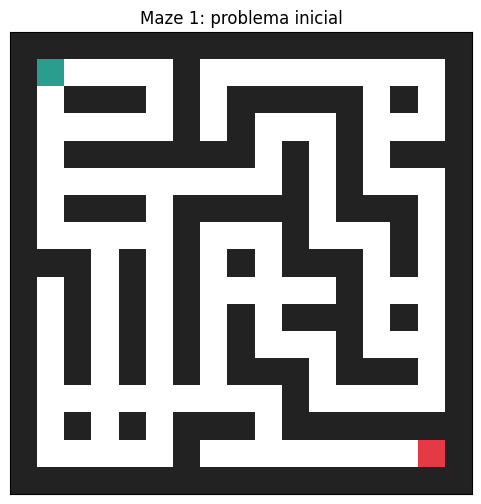

In [7]:
maze1 = Maze(MAZES_DIR / "maze1.txt")

print("Dimensiones:", maze1.height, "x", maze1.width)
print("Estado inicial:", maze1.start)
print("Estado objetivo:", maze1.goal)
print("Vecinos del estado inicial:", maze1.neighbors(maze1.start))

maze1.show(title="Maze 1: problema inicial")

### Pregunta para discutir

¿La posición del agente es suficiente para describir completamente un estado en este problema?

En este laberinto, sí: el comportamiento futuro depende únicamente de la celda actual, porque los muros no cambian y el agente no necesita recordar acciones anteriores. Es exactamente la misma situación que en el grafo `A–H`: el estado era la letra, no la secuencia de letras visitadas.

## 3. Estructuras comunes

`Node` y `reconstruct_path` son **copiados sin ningún cambio** desde el notebook de grafos. Un nodo de búsqueda guarda:

- `state`: estado actual (antes era una letra, ahora es una tupla `(fila, columna)`).
- `parent`: nodo desde el cual se llegó.
- `cost`: costo acumulado \(g(n)\).

In [8]:
class Node:
    def __init__(self, state, parent=None, cost=0):
        self.state = state
        self.parent = parent
        self.cost = cost

    def __repr__(self):
        return f"{self.state}(g={self.cost})"

In [9]:
def reconstruct_path(node):
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    return list(reversed(path))

## 4. DFS

DFS utiliza una **pila LIFO**. Los costos existen en el laberinto (cada paso cuesta 1), pero DFS no los utiliza para decidir qué nodo expandir.

`StackFrontier` es exactamente la misma clase del notebook de grafos.

In [10]:
class StackFrontier:
    def __init__(self):
        self.frontier = []

    def add(self, node):
        self.frontier.append(node)

    def contains_state(self, state):
        return any(node.state == state for node in self.frontier)

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        return self.frontier.pop()

    def states(self):
        return [node.state for node in self.frontier]

In [11]:
def depth_first_search(maze, start, goal, verbose=False):
    frontier = StackFrontier()
    frontier.add(Node(start))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node = frontier.remove()
        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo: {node.state}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if (
                child_state not in explored
                and not frontier.contains_state(child_state)
            ):
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )
                frontier.add(child)

    return None

Compara esta función con `depth_first_search` del notebook de grafos: son **idénticas**, salvo por la línea

```python
for child_state, edge_cost in maze.neighbors(node.state):
```

que en el grafo era

```python
for child_state, edge_cost in graph[node.state]:
```

Estados explorados: 69
Longitud del camino: 64
Costo del camino: 64


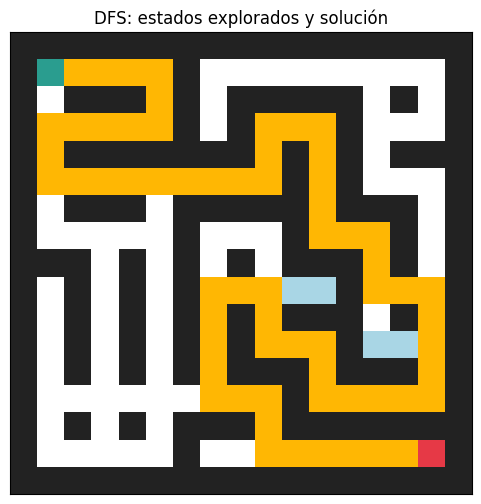

In [12]:
start, goal = maze1.start, maze1.goal

dfs_result = depth_first_search(maze1, start, goal)

print("Estados explorados:", len(dfs_result["expansion_order"]))
print("Longitud del camino:", len(dfs_result["path"]) - 1)
print("Costo del camino:", dfs_result["cost"])

maze1.show(
    path=dfs_result["path"],
    explored=set(dfs_result["expansion_order"]),
    title="DFS: estados explorados y solución"
)

### Observación

DFS sigue una rama tan profundamente como sea posible antes de retroceder. En este laberinto encuentra una solución, pero **claramente no la más corta**: compárala con el resultado de BFS en la siguiente sección.

## 5. BFS — actividad

BFS utiliza una **cola FIFO**.

### Tareas

1. Complete el método `remove` de `QueueFrontier`.
2. Complete `breadth_first_search`.
3. Verifique el orden de expansión y el camino encontrado.
4. Compare el resultado con DFS: ¿cuál encuentra el camino más corto?

In [13]:
class QueueFrontier(StackFrontier):
    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        # FIFO: sale el nodo que lleva más tiempo esperando, es decir el primero
        # de la lista. Pasar de pop() a pop(0) es la única diferencia con DFS;
        # add, contains_state, empty y states se heredan sin cambios.
        return self.frontier.pop(0)

In [14]:
def breadth_first_search(maze, start, goal, verbose=False):
    """BFS: el mismo cuerpo de DFS, cambiando la pila por una cola FIFO.

    Al sacar siempre el nodo más antiguo, la búsqueda avanza en anillos de radio
    creciente alrededor del inicio: primero todas las celdas a 1 paso, luego las
    de 2 pasos, y así. Por eso la primera vez que toca la meta lo hace por un
    camino de mínimo número de pasos.
    """
    frontier = QueueFrontier()
    frontier.add(Node(start))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node = frontier.remove()
        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo: {node.state}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            # Se descartan las celdas ya expandidas y las que ya esperan turno:
            # sin esto el laberinto, que está lleno de ciclos, no terminaría.
            if (
                child_state not in explored
                and not frontier.contains_state(child_state)
            ):
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )
                frontier.add(child)

    return None  # se agotó la frontier sin alcanzar la meta

Estados explorados: 106
Longitud del camino: 28
Costo del camino: 28


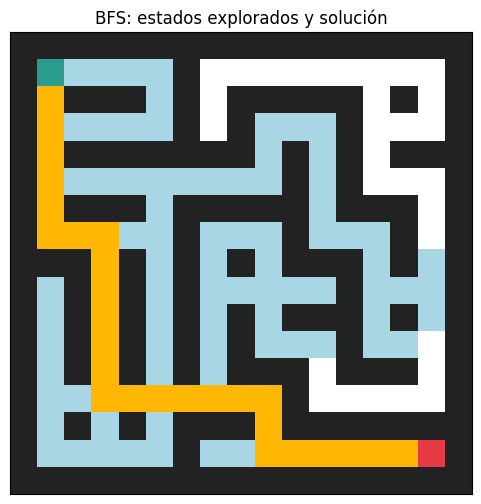

In [15]:
bfs_result = breadth_first_search(maze1, start, goal)

print("Estados explorados:", len(bfs_result["expansion_order"]))
print("Longitud del camino:", len(bfs_result["path"]) - 1)
print("Costo del camino:", bfs_result["cost"])

maze1.show(
    path=bfs_result["path"],
    explored=set(bfs_result["expansion_order"]),
    title="BFS: estados explorados y solución"
)

In [16]:
# Pruebas públicas para BFS
assert bfs_result["path"][0] == start
assert bfs_result["path"][-1] == goal
assert bfs_result["cost"] == 28
assert len(bfs_result["path"]) == 29

print("✓ BFS pasó las pruebas.")

✓ BFS pasó las pruebas.


### DFS frente a BFS

Cuando todas las acciones cuestan lo mismo:

- BFS expande los nodos por niveles y su primera solución es de profundidad mínima.
- DFS normalmente requiere menos memoria, pero su solución puede ser mucho más larga (en `maze1`, DFS encontró un camino de costo 64 frente al óptimo de 28).

## 6. UCS — implementación entregada

UCS utiliza una **cola de prioridad** y siempre expande el nodo con menor costo acumulado:

$$
g(n)
$$

Si aparece un camino más barato hacia un estado que ya estaba en la frontier, se conserva el de menor costo. `PriorityFrontier` es la misma clase del notebook de grafos.

In [17]:
class PriorityFrontier:
    def __init__(self):
        self.heap = []
        self.counter = count()

    def add(self, node, priority):
        # El contador permite desempatar respetando el orden de inserción.
        heapq.heappush(
            self.heap,
            (priority, next(self.counter), node)
        )

    def empty(self):
        return len(self.heap) == 0

    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        priority, _, node = heapq.heappop(self.heap)
        return node, priority

In [18]:
def uniform_cost_search(maze, start, goal, verbose=False):
    frontier = PriorityFrontier()
    frontier.add(Node(start, cost=0), priority=0)

    # Mejor costo conocido para cada estado.
    best_cost = {start: 0}

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # Ignorar entradas antiguas de la cola de prioridad.
        if node.cost != best_cost.get(node.state):
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: g={node.cost}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            new_cost = node.cost + edge_cost

            if new_cost < best_cost.get(child_state, float("inf")):
                best_cost[child_state] = new_cost

                child = Node(
                    state=child_state,
                    parent=node,
                    cost=new_cost
                )

                frontier.add(child, priority=new_cost)

    return None

Estados explorados: 106
Longitud del camino: 28
Costo óptimo: 28


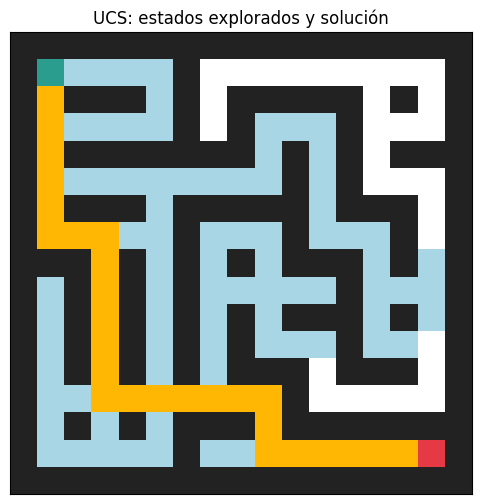

In [19]:
ucs_result = uniform_cost_search(maze1, start, goal)

print("Estados explorados:", len(ucs_result["expansion_order"]))
print("Longitud del camino:", len(ucs_result["path"]) - 1)
print("Costo óptimo:", ucs_result["cost"])

assert ucs_result["cost"] == 28

maze1.show(
    path=bfs_result["path"],
    explored=set(ucs_result["expansion_order"]),
    title="UCS: estados explorados y solución"
)

## 7. Heurística para Greedy y A*

$$
h(n) \approx \text{costo restante estimado desde } n \text{ hasta la meta}
$$

En el grafo, la heurística era una **tabla fija** (`heuristic["A"] = 4`, etc.) porque los estados eran letras conocidas de antemano. En el laberinto los estados son coordenadas, así que expresamos \(h(n)\) como una **función de la coordenada**: la distancia Manhattan entre el estado y la meta.

$$
h(n) = |r_n - r_{\text{meta}}| + |c_n - c_{\text{meta}}|
$$

Esta es la segunda (y última) diferencia real respecto al notebook de grafos: donde antes escribíamos `heuristic[state]`, ahora escribimos `heuristic(state, goal)`.

La heurística ignora los muros, por lo que puede subestimar la distancia real — nunca la sobrestima, así que sigue siendo **admisible** (y consistente, porque cada paso cuesta exactamente 1).

In [22]:
def manhattan(state, goal):
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])


def weighted_manhattan(state, goal, weight=3):

    return weight * manhattan(state, goal)


def zero_heuristic(state, goal):
    return 0


print("h(inicio) =", manhattan(start, goal))
print("h(meta)   =", manhattan(goal, goal))

h(inicio) = 28
h(meta)   = 0


## 8. Greedy Best-First Search — actividad

GBF utiliza únicamente:

$$
f(n) = h(n)
$$

### Tareas

1. Reutilice `PriorityFrontier`.
2. Use la heurística como prioridad.
3. No use el costo acumulado para decidir qué nodo expandir.
4. Retorne el camino, orden de expansión y costo real del camino.

In [20]:
def greedy_best_first_search(maze, heuristic, start, goal, verbose=False):
    """GBF: la prioridad es únicamente h(n), lo que se estima que falta.

    Frente a la versión del notebook de grafos solo cambia una cosa: heuristic
    ya no es una tabla que se consulta con heuristic[state], sino una función
    que se llama con heuristic(state, goal).

    El costo se sigue acumulando en cada nodo, pero solo para poder reportar al
    final el costo real del camino. La frontier nunca lo mira.
    """
    frontier = PriorityFrontier()
    frontier.add(Node(start, cost=0), priority=heuristic(start, goal))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # Una misma celda puede haber entrado a la cola por varias ramas. Como
        # aquí no se comparan costos, basta quedarse con la primera que salga.
        if node.state in explored:
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: h={priority}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if child_state not in explored:
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )

                # La prioridad ignora child.cost: ahí está el sesgo de GBF.
                frontier.add(child, priority=heuristic(child_state, goal))

    return None

Estados explorados: 33
Longitud del camino: 32
Costo del camino: 32


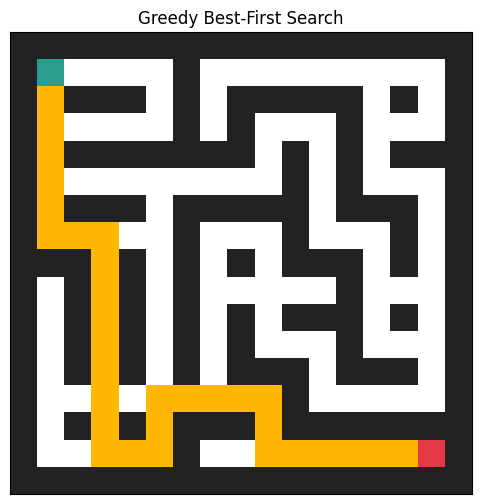

In [23]:
greedy_result = greedy_best_first_search(maze1, manhattan, start, goal)

print("Estados explorados:", len(greedy_result["expansion_order"]))
print("Longitud del camino:", len(greedy_result["path"]) - 1)
print("Costo del camino:", greedy_result["cost"])

maze1.show(
    path=greedy_result["path"],
    explored=set(greedy_result["expansion_order"]),
    title="Greedy Best-First Search"
)

In [24]:
# Pruebas públicas para Greedy
assert greedy_result["path"][0] == start
assert greedy_result["path"][-1] == goal
assert greedy_result["cost"] == 32

print("✓ Greedy pasó las pruebas.")

✓ Greedy pasó las pruebas.


### La trampa de Greedy

Greedy exploró muy pocos estados (comparado con BFS/UCS), pero su camino cuesta **32**, no **28** como el óptimo. `maze1` fue construido específicamente para mostrar esto: cerca de la meta hay un pasillo que *parece* prometedor según la distancia Manhattan, pero que obliga a un rodeo. Greedy entra ahí porque solo mira $h(n)$ y nunca reconsidera lo que ya gastó en $g(n)$.

## 9. A* — actividad

A* combina costo acumulado y heurística:

$$
f(n) = g(n) + h(n)
$$

### Tareas

1. Adapte la implementación de UCS.
2. Mantenga `best_cost` para permitir mejoras de ruta.
3. Use `new_cost + heuristic(child_state, goal)` como prioridad.
4. Verifique que encuentre un camino óptimo.

In [25]:
def a_star_search(maze, heuristic, start, goal, verbose=False):
    """A*: la prioridad es f(n) = g(n) + h(n), lo recorrido más lo estimado.

    Es UCS con la heurística sumada a la prioridad. Se conserva best_cost por
    dos motivos: descartar entradas obsoletas de la cola, y volver a encolar una
    celda cuando aparece una ruta más barata hacia ella. Lo segundo es lo que
    protege el resultado si la heurística deja de ser consistente, como ocurre
    más adelante con la versión ponderada.
    """
    frontier = PriorityFrontier()
    frontier.add(Node(start, cost=0), priority=heuristic(start, goal))

    # Mejor costo conocido para cada estado.
    best_cost = {start: 0}

    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # heapq no permite actualizar la prioridad de un elemento ya insertado,
        # así que las versiones caras de un estado siguen en el heap. Se las
        # reconoce porque su g ya no coincide con el mejor costo registrado.
        if node.cost != best_cost.get(node.state):
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: g={node.cost}, f={priority}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        for child_state, edge_cost in maze.neighbors(node.state):
            new_cost = node.cost + edge_cost

            # Solo se encola si mejora la ruta conocida hacia esa celda.
            if new_cost < best_cost.get(child_state, float("inf")):
                best_cost[child_state] = new_cost

                child = Node(
                    state=child_state,
                    parent=node,
                    cost=new_cost
                )

                frontier.add(
                    child,
                    priority=new_cost + heuristic(child_state, goal)
                )

    return None

Estados explorados: 59
Longitud del camino: 28
Costo óptimo: 28


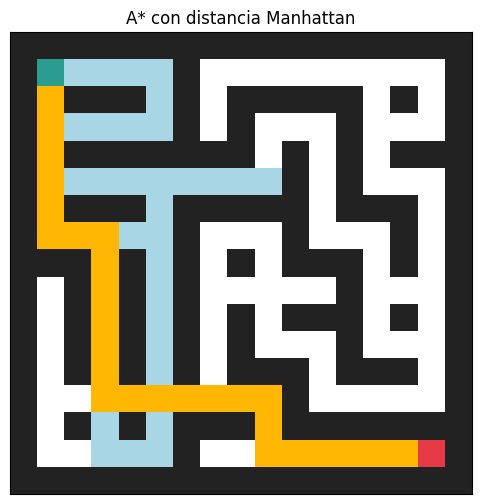

In [26]:
astar_result = a_star_search(maze1, manhattan, start, goal)

print("Estados explorados:", len(astar_result["expansion_order"]))
print("Longitud del camino:", len(astar_result["path"]) - 1)
print("Costo óptimo:", astar_result["cost"])

maze1.show(
    path=astar_result["path"],
    explored=set(astar_result["expansion_order"]),
    title="A* con distancia Manhattan"
)

In [27]:
# Pruebas públicas para A*
assert astar_result["path"][0] == start
assert astar_result["path"][-1] == goal
assert astar_result["cost"] == 28

print("✓ A* pasó las pruebas.")

✓ A* pasó las pruebas.


## 10. Comparación final

Resultados sobre `maze1` (17x17, de `(1, 1)` a `(15, 15)`). Los cinco algoritmos
comparten el mismo cuerpo; lo único que cambia es el criterio con el que la frontier
decide quién sale primero.

| Algoritmo | Tipo de frontier | Prioridad | Estados explorados | Costo | ¿Óptimo? |
|---|---|---|---:|---:|---:|
| DFS | Pila | LIFO | 69 | 64 | No |
| BFS | Cola | FIFO | 106 | 28 | Sí |
| UCS | Cola de prioridad | \(g(n)\) | 106 | 28 | Sí |
| Greedy | Cola de prioridad | \(h(n)\) | 33 | 32 | No |
| A* | Cola de prioridad | \(g(n)+h(n)\) | 59 | 28 | Sí |

Lo que salta a la vista es que **explorar poco y encontrar el óptimo son objetivos
distintos**. Greedy es el que menos explora (33) y da el segundo peor camino; BFS y
UCS dan el óptimo pero recorren casi todo el laberinto (106); A* es el único que
consigue las dos cosas: mismo costo 28 que UCS, con 47 estados menos. Eso es
exactamente lo que aporta una heurística admisible.

DFS explora poco (69) por accidente, no por mérito: se lanza por un pasillo y tiene
suerte de que desemboque en la meta. Su camino de 64 pasos es más del doble del óptimo.

### Preguntas de cierre

**1. ¿Qué algoritmos garantizan el camino de menor número de pasos?**

BFS, por construcción: al vaciar la frontier por niveles, la primera vez que alcanza
la meta lo hace por un camino de longitud mínima.

En este problema **UCS y A\* también lo consiguen**, pero por otra razón: como cada
paso cuesta exactamente 1, minimizar el costo y minimizar el número de pasos son el
mismo objetivo. Si el laberinto tuviera celdas con costos distintos (barro, agua),
esa coincidencia se rompería y solo BFS seguiría garantizando el mínimo de pasos.
DFS (64) y Greedy (32) no dan garantía alguna.

**2. ¿Qué algoritmos garantizan el camino de menor costo?**

UCS siempre, porque expande en orden creciente de \(g(n)\): cuando extrae la meta ya
descartó toda ruta más barata. A\* lo garantiza cuando la heurística es admisible, y
Manhattan lo es aquí (ignora los muros, así que nunca puede sobreestimar los pasos
reales). Ambos dan 28.

BFS también da 28, pero eso **no es una garantía de BFS**: es consecuencia de que
todos los pasos cuestan 1. El experimento de la heurística ponderada muestra el otro
lado: al perder la admisibilidad, A\* devuelve 16 en `maze2` donde el óptimo es 12.

**3. ¿Por qué Greedy puede encontrar un camino subóptimo aunque explore muy pocos estados?**

Son dos caras de lo mismo. Greedy avanza siempre hacia donde \(h(n)\) es menor, lo que
lo lleva casi en línea recta a la meta y explica que solo expanda 33 estados. Pero esa
misma regla lo hace incapaz de revisar una decisión: nunca compara lo que ya gastó
(\(g(n)\)) contra lo que le falta. Cuando el pasillo que "apuntaba" a la meta obliga a
un rodeo, Greedy ya se comprometió y termina con 32 pasos en vez de 28.

Explorar poco es justamente lo que lo vuelve frágil: no mira alternativas.

**4. ¿Qué ocurre con A\* si \(h(n) = 0\) para todos los nodos? ¿En qué algoritmo del notebook de grafos se convertiría?**

Se convierte en **UCS**. Con \(h(n)=0\), \(f(n) = g(n) + 0 = g(n)\), y la cola de
prioridad queda ordenada por el mismo criterio.

No hace falta creerlo: el experimento de la Parte 2 lo comprueba. UCS y A\* con
`zero_heuristic` expanden los mismos 106 estados **en el mismo orden**, elemento por
elemento. Es el caso extremo de heurística admisible: nunca sobreestima, pero tampoco
informa, así que conserva la optimalidad y pierde toda capacidad de podar.

**5. ¿Qué efecto tiene el orden en que `neighbors()` genera las direcciones sobre DFS y BFS?**

En DFS es determinante; en BFS es casi irrelevante. El experimento de la Parte 2
prueba las 24 permutaciones de las cuatro direcciones sobre `maze1`:

- **DFS** produce caminos de entre **32 y 84 pasos** según el orden, y expande entre
  33 y 129 estados. El orden en que se escriben las direcciones cambia el resultado
  por un factor de más de 2.5. Es lógico: la pila devuelve el último vecino apilado,
  así que la última dirección de la lista decide por dónde se lanza la búsqueda.
- **BFS** devuelve **28 pasos en las 24 permutaciones**, sin excepción. Solo aparecen
  2 caminos distintos, ambos de longitud mínima, y el número de estados explorados se
  mueve apenas entre 105 y 108. El orden decide *cuál* de los caminos óptimos se
  reporta, nunca su longitud.

UCS y A\* tampoco se ven afectados en el costo, porque el desempate lo resuelve la
prioridad de la cola y no la posición en la lista de vecinos.

---

# Parte 2 — Más allá de la traducción

Todo lo anterior fue una traducción 1 a 1 del notebook de grafos. Lo que sigue son
experimentos que **no tienen equivalente** en el grafo `A–H`, porque dependen de que
el problema viva en un espacio con estructura geométrica: más de un laberinto, una
heurística que se puede calcular en vez de tabular, y direcciones cuyo orden se puede
permutar.

Cada experimento responde una de las preguntas de cierre con una medición:

| Experimento | Pregunta que responde |
|---|---|
| Heurística ponderada \(w=3\) | 2 — cuándo se pierde la garantía de optimalidad |
| \(h(n)=0\) frente a UCS | 4 — en qué se convierte A* sin heurística |
| Laberinto sin solución | qué pasa cuando la meta es inalcanzable |
| Permutación de direcciones | 5 — cuánto depende cada algoritmo del orden de vecinos |

## Comparación experimental sobre `maze1`

Automatizamos la tabla de la sección anterior y agregamos una comparación visual del esfuerzo de búsqueda (estados explorados) de cada algoritmo.

In [28]:
def summarize_results(results):
    """Convierte los resultados en filas de resumen.

    Un algoritmo que devolvió None (meta inalcanzable) deja los campos numéricos
    en None en vez de reventar: más adelante se usa con un laberinto sin solución.
    """
    rows = []

    for name, result in results.items():
        if result is None:
            rows.append({
                "algoritmo": name,
                "estados_explorados": None,
                "longitud_camino": None,
                "costo_camino": None,
            })
        else:
            rows.append({
                "algoritmo": name,
                "estados_explorados": len(result["expansion_order"]),
                "longitud_camino": len(result["path"]) - 1,
                "costo_camino": result["cost"],
            })

    return rows


def validate_path(maze, path):
    """Comprueba que un camino sea físicamente recorrible en el laberinto.

    Que el costo dé bien no basta: un error en reconstruct_path o en el manejo de
    padres puede producir un camino que salte entre celdas no contiguas o pase por
    encima de un muro. Aquí se verifican los extremos, que cada par de pasos
    consecutivos sea adyacente, y que ninguna celda del camino sea muro.
    """
    if not path or path[0] != maze.start or path[-1] != maze.goal:
        return False

    for (r1, c1), (r2, c2) in zip(path, path[1:]):
        if abs(r1 - r2) + abs(c1 - c2) != 1:  # celdas no contiguas
            return False
        if maze.walls[r2, c2]:
            return False

    return True


def print_table(results, titulo="Comparación de algoritmos"):
    """Imprime la tabla comparativa marcando cuáles alcanzaron el costo mínimo."""
    rows = summarize_results(results)
    costos = [row["costo_camino"] for row in rows if row["costo_camino"] is not None]
    optimo = min(costos) if costos else None

    print(titulo)
    print(f"{'Algoritmo':<10}{'Explorados':>12}{'Pasos':>8}{'Costo':>8}{'Óptimo':>9}")
    print("-" * 47)

    for row in rows:
        if row["costo_camino"] is None:
            print(f"{row['algoritmo']:<10}{'-':>12}{'-':>8}{'-':>8}{'sin sol.':>9}")
            continue

        marca = "sí" if row["costo_camino"] == optimo else "no"
        print(
            f"{row['algoritmo']:<10}"
            f"{row['estados_explorados']:>12}"
            f"{row['longitud_camino']:>8}"
            f"{row['costo_camino']:>8}"
            f"{marca:>9}"
        )

In [29]:
results_maze1 = {
    "DFS": dfs_result,
    "BFS": bfs_result,
    "UCS": ucs_result,
    "Greedy": greedy_result,
    "A*": astar_result,
}

# Ningún algoritmo debería reportar un camino que no se pueda recorrer.
for name, result in results_maze1.items():
    assert validate_path(maze1, result["path"]), f"{name} devolvió un camino inválido"

print_table(results_maze1, titulo="Resultados sobre maze1")

summary_maze1 = summarize_results(results_maze1)

Resultados sobre maze1
Algoritmo   Explorados   Pasos   Costo   Óptimo
-----------------------------------------------
DFS                 69      64      64       no
BFS                106      28      28       sí
UCS                106      28      28       sí
Greedy              33      32      32       no
A*                  59      28      28       sí


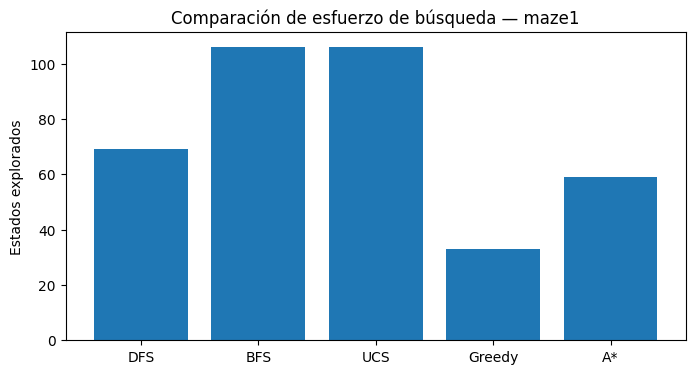

In [30]:
algorithms = [row["algoritmo"] for row in summary_maze1]
explored_counts = [row["estados_explorados"] for row in summary_maze1]

plt.figure(figsize=(8, 4))
plt.bar(algorithms, explored_counts)
plt.ylabel("Estados explorados")
plt.title("Comparación de esfuerzo de búsqueda — maze1")
plt.show()

## Experimento: una heurística no admisible

Podemos multiplicar Manhattan por un factor mayor que 1:

$$
h'(n) = w \cdot h(n), \qquad w > 1
$$

Esta heurística puede **sobreestimar** el costo real, así que deja de ser admisible. El algoritmo suele comportarse de forma más agresiva y explorar menos estados, pero pierde la garantía de optimalidad.

maze1 (17x17)
  A* con Manhattan (w=1, admisible) -> costo  28, explorados  59
  A* con Manhattan ponderada (w=3)  -> costo  28, explorados  35
  Aquí conservó el óptimo y aun así exploró menos, pero eso depende del mapa: sin admisibilidad no hay garantía.

maze2 (9x11)
  A* con Manhattan (w=1, admisible) -> costo  12, explorados  19
  A* con Manhattan ponderada (w=3)  -> costo  16, explorados  17
  Perdió la optimalidad a cambio de explorar menos.



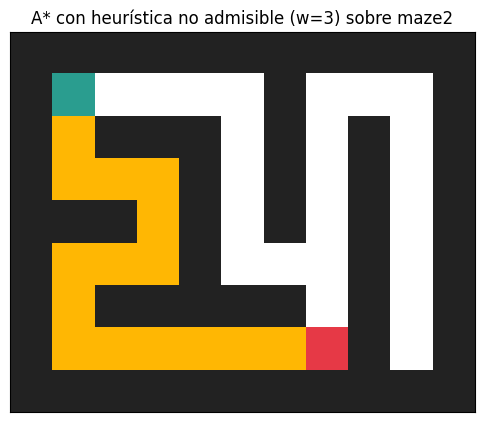

In [31]:
maze2 = Maze(MAZES_DIR / "maze2.txt")


def comparar_pesos(maze, nombre):
    """Corre A* con Manhattan y con Manhattan ponderada sobre el mismo laberinto."""
    start, goal = maze.start, maze.goal

    admisible = a_star_search(maze, manhattan, start, goal)
    ponderada = a_star_search(maze, weighted_manhattan, start, goal)

    print(f"{nombre} ({maze.height}x{maze.width})")
    print(f"  A* con Manhattan (w=1, admisible) -> costo {admisible['cost']:>3}, "
          f"explorados {len(admisible['expansion_order']):>3}")
    print(f"  A* con Manhattan ponderada (w=3)  -> costo {ponderada['cost']:>3}, "
          f"explorados {len(ponderada['expansion_order']):>3}")

    if ponderada["cost"] > admisible["cost"]:
        print("  Perdió la optimalidad a cambio de explorar menos.")
    else:
        print("  Aquí conservó el óptimo y aun así exploró menos, pero eso "
              "depende del mapa: sin admisibilidad no hay garantía.")
    print()

    return admisible, ponderada


comparar_pesos(maze1, "maze1")
_, ponderada_maze2 = comparar_pesos(maze2, "maze2")

# Se dibuja maze2, que es donde el rodeo de la heurística ponderada sí aparece.
maze2.show(
    path=ponderada_maze2["path"],
    explored=set(ponderada_maze2["expansion_order"]),
    title="A* con heurística no admisible (w=3) sobre maze2"
)

Los dos laberintos muestran caras distintas del mismo intercambio:

- En **maze1** la versión ponderada mantuvo el costo óptimo (28) y aun así bajó de
  59 a 35 estados explorados. Salió gratis, pero por cómo está armado ese mapa,
  no porque la teoría lo asegure.
- En **maze2** sí cobró el precio: exploró 17 estados en vez de 19, y a cambio
  devolvió un camino de costo **16** frente al óptimo de **12**.

Es el mismo fenómeno de Greedy en `maze1`, en otro punto del espectro. El peso \(w\)
regula cuánto pesa \(h(n)\) frente a \(g(n)\): con \(w=1\) tenemos A* estándar y la
garantía de optimalidad; a medida que \(w\) crece, \(g(n)\) pierde influencia y el
algoritmo se parece cada vez más a Greedy puro, más rápido pero menos confiable.

Conviene notar que "explorar menos" y "encontrar peor camino" no van siempre juntos.
En maze2 el ahorro fue de dos estados y la pérdida de cuatro unidades de costo: un
mal negocio. La heurística ponderada solo compensa cuando el espacio de búsqueda es
grande y basta con una solución razonablemente buena.

## Experimento: el otro extremo, $h(n) = 0$

Si la heurística ponderada empuja A* hacia Greedy, quitarle la heurística lo empuja
en la dirección contraria. Con \(h(n) = 0\) la prioridad queda en

$$
f(n) = g(n) + 0 = g(n)
$$

que es exactamente el criterio de UCS. La afirmación se puede comprobar en vez de
creerla: si ambos algoritmos son el mismo, no basta con que coincida el costo, debe
coincidir el **orden de expansión completo**, estado por estado.

In [32]:
ucs_maze1 = uniform_cost_search(maze1, start, goal)
astar_cero = a_star_search(maze1, zero_heuristic, start, goal)

print(f"UCS        -> costo {ucs_maze1['cost']}, "
      f"explorados {len(ucs_maze1['expansion_order'])}")
print(f"A* con h=0 -> costo {astar_cero['cost']}, "
      f"explorados {len(astar_cero['expansion_order'])}")

mismo_orden = ucs_maze1["expansion_order"] == astar_cero["expansion_order"]
print(f"\n¿Mismo orden de expansión, estado por estado? {'sí' if mismo_orden else 'no'}")

assert mismo_orden, "Con h=0, A* debería reproducir UCS exactamente."

UCS        -> costo 28, explorados 106
A* con h=0 -> costo 28, explorados 106

¿Mismo orden de expansión, estado por estado? sí


## Comparación en los tres laberintos

Ejecutamos los cinco algoritmos sobre los tres mapas de la carpeta `mazes/`:

- `maze1.txt` (17x17), el del taller.
- `maze2.txt` (9x11), más pequeño y con otra topología, para confirmar que las
  conclusiones no dependen de un solo mapa.
- `maze3_sin_solucion.txt` (5x9), donde `B` existe pero está encerrado detrás de un
  muro. Es el caso que ningún mapa anterior cubre: los cinco algoritmos deben agotar
  la frontier y devolver `None` en vez de fallar o quedarse colgados.

Ese tercer caso es la razón por la que `summarize_results` tolera `None`.

In [33]:
def run_all(maze, heuristic=manhattan):
    """Corre los cinco algoritmos sobre el mismo laberinto."""
    start, goal = maze.start, maze.goal

    return {
        "DFS": depth_first_search(maze, start, goal),
        "BFS": breadth_first_search(maze, start, goal),
        "UCS": uniform_cost_search(maze, start, goal),
        "Greedy": greedy_best_first_search(maze, heuristic, start, goal),
        "A*": a_star_search(maze, heuristic, start, goal),
    }


ARCHIVOS = ["maze1.txt", "maze2.txt", "maze3_sin_solucion.txt"]

all_summaries = []

for filename in ARCHIVOS:
    current_maze = Maze(MAZES_DIR / filename)
    current_results = run_all(current_maze)

    # Donde hay camino, debe ser recorrible de verdad.
    for name, result in current_results.items():
        if result is not None:
            assert validate_path(current_maze, result["path"]), \
                f"{name} devolvió un camino inválido en {filename}"

    print_table(current_results, titulo=f"\n{filename} ({current_maze.height}x{current_maze.width})")

    for row in summarize_results(current_results):
        row["laberinto"] = filename
        all_summaries.append(row)

# En el laberinto sin solución ninguno debe reportar camino.
sin_solucion = [
    row for row in all_summaries
    if row["laberinto"] == "maze3_sin_solucion.txt"
]
assert all(row["costo_camino"] is None for row in sin_solucion), \
    "Un algoritmo reportó camino en un laberinto sin solución"

print("\nLos cinco algoritmos terminan y devuelven None cuando la meta es inalcanzable.")


maze1.txt (17x17)
Algoritmo   Explorados   Pasos   Costo   Óptimo
-----------------------------------------------
DFS                 69      64      64       no
BFS                106      28      28       sí
UCS                106      28      28       sí
Greedy              33      32      32       no
A*                  59      28      28       sí

maze2.txt (9x11)
Algoritmo   Explorados   Pasos   Costo   Óptimo
-----------------------------------------------
DFS                 13      12      12       sí
BFS                 27      12      12       sí
UCS                 27      12      12       sí
Greedy              17      16      16       no
A*                  19      12      12       sí

maze3_sin_solucion.txt (5x9)
Algoritmo   Explorados   Pasos   Costo   Óptimo
-----------------------------------------------
DFS                  -       -       - sin sol.
BFS                  -       -       - sin sol.
UCS                  -       -       - sin sol.
Greedy               

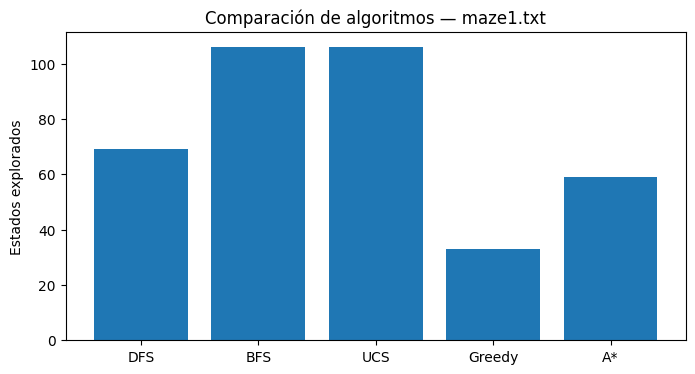

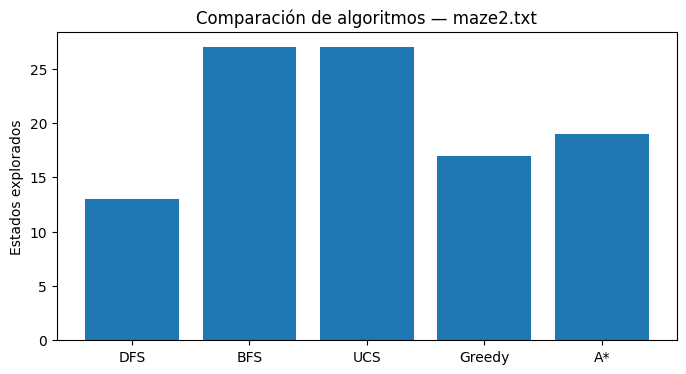

maze3_sin_solucion.txt: sin solución, no se grafica.


In [34]:
for filename in ARCHIVOS:
    rows = [
        row for row in all_summaries
        if row["laberinto"] == filename and row["estados_explorados"] is not None
    ]

    # El laberinto sin solución no tiene nada que graficar.
    if not rows:
        print(f"{filename}: sin solución, no se grafica.")
        continue

    labels = [row["algoritmo"] for row in rows]
    values = [row["estados_explorados"] for row in rows]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, values)
    plt.ylabel("Estados explorados")
    plt.title(f"Comparación de algoritmos — {filename}")
    plt.show()

## Experimento: ¿cuánto importa el orden de las direcciones?

`Maze.neighbors` genera los vecinos siempre en el mismo orden: arriba, abajo,
izquierda, derecha. Esa elección es arbitraria, y la pregunta 5 apunta a si el
resultado depende de ella.

Para medirlo se hereda de `Maze` una versión cuyo orden es configurable, y se prueban
las **24 permutaciones** de las cuatro direcciones. Heredar en vez de modificar `Maze`
mantiene intacto el comportamiento del resto del notebook.

Si un algoritmo da garantías reales, el orden no debería alterar la calidad de su
solución, solo el camino concreto que reporta.

In [35]:
from itertools import permutations


class MazeConOrden(Maze):
    """Maze cuyo orden de exploración de direcciones se puede configurar.

    Hereda todo de Maze y solo reemplaza neighbors(), de modo que el resto del
    notebook sigue usando la clase original sin enterarse.
    """

    DIRECCIONES = {
        "arriba": (-1, 0),
        "abajo": (1, 0),
        "izquierda": (0, -1),
        "derecha": (0, 1),
    }

    def __init__(self, filename, orden=("arriba", "abajo", "izquierda", "derecha")):
        super().__init__(filename)
        self.orden = orden

    def neighbors(self, state):
        row, col = state
        valid = []

        for nombre in self.orden:
            dr, dc = self.DIRECCIONES[nombre]
            r, c = row + dr, col + dc

            if 0 <= r < self.height and 0 <= c < self.width and not self.walls[r, c]:
                valid.append(((r, c), 1))

        return valid


base = ["arriba", "abajo", "izquierda", "derecha"]

dfs_pasos = []
bfs_pasos = []
bfs_caminos = set()

for orden in permutations(base):
    m = MazeConOrden(MAZES_DIR / "maze1.txt", orden=orden)

    d = depth_first_search(m, m.start, m.goal)
    b = breadth_first_search(m, m.start, m.goal)

    dfs_pasos.append(len(d["path"]) - 1)
    bfs_pasos.append(len(b["path"]) - 1)
    bfs_caminos.add(tuple(b["path"]))

print(f"Se probaron {len(dfs_pasos)} permutaciones de direcciones sobre maze1.\n")

print(f"DFS  pasos: mínimo {min(dfs_pasos)}, máximo {max(dfs_pasos)}, "
      f"valores distintos {sorted(set(dfs_pasos))}")
print(f"BFS  pasos: mínimo {min(bfs_pasos)}, máximo {max(bfs_pasos)}, "
      f"valores distintos {sorted(set(bfs_pasos))}")
print(f"\nBFS encontró {len(bfs_caminos)} camino(s) distinto(s), "
      f"todos de longitud {bfs_pasos[0]}.")

# BFS garantiza longitud mínima sin importar el orden; DFS no garantiza nada.
assert len(set(bfs_pasos)) == 1, "BFS debería dar siempre la misma longitud."
assert len(set(dfs_pasos)) > 1, "DFS debería variar con el orden de direcciones."

Se probaron 24 permutaciones de direcciones sobre maze1.

DFS  pasos: mínimo 32, máximo 84, valores distintos [32, 36, 64, 68, 76, 80, 84]
BFS  pasos: mínimo 28, máximo 28, valores distintos [28]

BFS encontró 2 camino(s) distinto(s), todos de longitud 28.


### Propiedades teóricas

| Algoritmo | Estrategia | Completo | Óptimo |
|---|---|---:|---:|
| DFS | Nodo más profundo | No, en espacios infinitos | No |
| BFS | Nodo menos profundo | Sí, con ramificación finita | Sí, con costos iguales |
| UCS | Menor \(g(n)\) | Sí, con costos positivos | Sí |
| Greedy | Menor \(h(n)\) | No siempre | No |
| A* | Menor \(g(n)+h(n)\) | Sí, bajo condiciones estándar | Sí, con heurística admisible |

La eficiencia observada depende de la estructura de cada laberinto y del orden en que `neighbors()` genera las direcciones.

## Reto de implementación (extensión conceptual, no evaluada)

Elige **una** de estas variantes y formalízala como problema de búsqueda antes de tocar código:

- movimientos diagonales;
- llaves y puertas;
- múltiples metas;
- celdas con costos distintos por dirección de entrada;
- un enemigo que cambia de posición en cada paso del agente.

Para la variante elegida, especifica por escrito:

1. **Estado:** ¿qué información mínima necesitas para que el estado determine completamente el comportamiento futuro? (Pista: si eliges "enemigo que se mueve", la posición del agente sola ya no basta — el estado también debe incluir la posición del enemigo.)
2. **Acciones** disponibles en cada estado.
3. **Modelo de transición.**
4. **Costo de cada acción.**
5. **Heurística propuesta** y si es admisible: da un argumento, no solo una intuición.

## Cierre

Las búsquedas no informadas (DFS, BFS, UCS) utilizan únicamente la estructura del problema. Las búsquedas informadas (Greedy, A*) incorporan conocimiento adicional mediante una heurística.

Lo que debería quedar claro después de este notebook:

- **El algoritmo no cambió entre el grafo y el laberinto.** Cambió la representación del problema (`graph[state]` → `maze.neighbors(state)`) y cómo se calcula la heurística (tabla fija → función de la coordenada).
- **Greedy y A* ponderado comparten el mismo defecto:** ignoran (total o parcialmente) el costo ya acumulado, y por eso pueden caer en rutas subóptimas cuando la heurística "promete" de más.
- **UCS y A* con heurística admisible son los únicos con garantía de optimalidad** cuando los costos no son uniformes.

La elección del algoritmo en un problema real depende de: si necesitamos una solución óptima, si los costos son uniformes, cuánta memoria tenemos, qué tan buena es la heurística, y qué tan grande es el espacio de estados.